# Python ile Bütünleşik Makine Öğrenmesi ve Derin Öğrenme Projesi

- Bu proje; regresyon, kümeleme, metin duygu analizi ve görüntü sınıflandırma yöntemlerini Colab ortamında menü
tabanlı tek bir uygulamada birleştirmektedir. Google Drive'dan gdown ile çekilen veri setleriyle çalışan program, her
modülün yöntem ve başarı metriklerini sonuclar.txt dosyasına kaydeder. Menü; 4 analiz yöntemi ve bir çıkış seçeneği
olmak üzere 5 adımdan oluşur.

In [ ]:
import os
import io
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

SONUC_DOSYASI = "sonuclar.txt"

In [ ]:
!pip install -q gdown
import gdown

gdown.download('https://drive.google.com/uc?id=1WejIwOmtTINRgXB8e9Ejqy7iBo_Biteo', 'proje_ev_fiyatlari.csv', quiet = False)
gdown.download('https://drive.google.com/uc?id=1r3iFh2tIGjRdw4PvEEsEJNxMcUD-CZOP', 'proje_musteri_segmentasyonu.csv', quiet = False)
gdown.download('https://drive.google.com/uc?id=1JEglUu9b3ERxDxahWYt5TnzxhgyVuPqh', 'IMDB_Dataset.csv', quiet = False)

Downloading...
From: https://drive.google.com/uc?id=1WejIwOmtTINRgXB8e9Ejqy7iBo_Biteo
To: /content/proje_ev_fiyatlari.csv
100%|██████████| 10.6k/10.6k [00:00<00:00, 23.6MB/s]
Downloading...
From: https://drive.google.com/uc?id=1r3iFh2tIGjRdw4PvEEsEJNxMcUD-CZOP
To: /content/proje_musteri_segmentasyonu.csv
100%|██████████| 4.04k/4.04k [00:00<00:00, 3.79MB/s]
Downloading...
From: https://drive.google.com/uc?id=1JEglUu9b3ERxDxahWYt5TnzxhgyVuPqh
To: /content/IMDB_Dataset.csv
100%|██████████| 66.2M/66.2M [00:00<00:00, 178MB/s]


'IMDB_Dataset.csv'

In [ ]:
def sonuc_kaydet(baslik, icerik):
    with open(SONUC_DOSYASI, "a", encoding = "utf-8") as f:
        f.write("=" * 45 + "\n")
        f.write(f"{baslik}\n")
        f.write("-" * 45 + "\n")
        f.write(icerik + "\n\n")
    print(f"\n'{baslik}' sonucu {SONUC_DOSYASI} dosyasına kaydedildi.\n")

# BÖLÜM 1 - REGRESYON ANALİZİ

In [ ]:
def modul1_regresyon(dosya_yolu = "proje_ev_fiyatlari.csv"):
    print("\n--- Regresyon Analizi başlıyor ---\n")

    if not os.path.exists(dosya_yolu):
        print(f"HATA: '{dosya_yolu}' bulunamadı. Lütfen önce dosyayı yükleyin.")
        return

    df = pd.read_csv(dosya_yolu)
    print("Veri seti önizleme:")
    print(df.head())

    X = df[["alan", "oda_sayisi", "bina_yasi", "merkeze_uzaklik", "kat"]]
    y = df["fiyat"]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)

    sonuclar = {}

    # 1) Doğrusal Regresyon
    lr = LinearRegression()
    lr.fit(X_train_s, y_train)
    pred = lr.predict(X_test_s)
    sonuclar["Doğrusal Regresyon"] = (mean_squared_error(y_test, pred), r2_score(y_test, pred))

    # 2) Ridge
    ridge = Ridge(alpha = 1.0)
    ridge.fit(X_train_s, y_train)
    pred = ridge.predict(X_test_s)
    sonuclar["Ridge"] = (mean_squared_error(y_test, pred), r2_score(y_test, pred))

    # 3) PCR (PCA + Doğrusal Regresyon)
    n_bilesen = 3
    pca = PCA(n_components = n_bilesen)
    X_train_pca = pca.fit_transform(X_train_s)
    X_test_pca = pca.transform(X_test_s)
    pcr = LinearRegression()
    pcr.fit(X_train_pca, y_train)
    pred = pcr.predict(X_test_pca)
    sonuclar[f"PCR ({n_bilesen} bileşen)"] = (mean_squared_error(y_test, pred), r2_score(y_test, pred))

    # 4) PLS
    pls = PLSRegression(n_components = n_bilesen)
    pls.fit(X_train_s, y_train)
    pred = pls.predict(X_test_s).ravel()
    sonuclar[f"PLS ({n_bilesen} bileşen)"] = (mean_squared_error(y_test, pred), r2_score(y_test, pred))

    # 5) Yapay Sinir Ağı (MLP)
    mlp = MLPRegressor(
        hidden_layer_sizes = (64, 32),
        activation = "relu",
        max_iter = 4000,
        random_state = 42,
    )
    mlp.fit(X_train_s, y_train)
    pred = mlp.predict(X_test_s)
    sonuclar["Yapay Sinir Ağı"] = (mean_squared_error(y_test, pred), r2_score(y_test, pred))

    # Sonuçları ekrana yazdır
    print(f"\n{'Model':<25}{'MSE':>12}{'R^2':>10}")
    print("-" * 47)
    metin_satirlari = []
    for model_adi, (mse, r2) in sonuclar.items():
        satir = f"{model_adi:<25}{mse:>12.2f}{r2:>10.3f}"
        print(satir)
        metin_satirlari.append(satir)

    en_iyi_model = min(sonuclar, key = lambda k: sonuclar[k][0])
    yorum = (
        f"En düşük MSE'ye sahip model: {en_iyi_model} "
        f"(MSE = {sonuclar[en_iyi_model][0]:.2f}, R2 = {sonuclar[en_iyi_model][1]:.3f}).\n\n"
        "Doğrusal modeller (Doğrusal, Ridge, PLS) genelde birbirine yakın ve iyi sonuç verir.\n"
        "PCR, az sayıda bileşenle bilgi kaybettiği için genelde daha düşük başarı gösterir;\n"
        "PLS ise bileşenleri hedef değişkeni de dikkate alarak oluşturduğu için PCR'den daha iyi sonuç verir.\n"
        "Veride doğrusal olmayan etkiler varsa yapay sinir ağı diğer modellerden daha düşük hata elde edebilir."
    )
    print("\nYorum:\n" + yorum)

    icerik = (
        "Veri seti: " + dosya_yolu + "\n\n"
        + "\n".join(metin_satirlari)
        + "\n\nYorum:\n" + yorum
    )
    sonuc_kaydet("Regresyon Analizi", icerik)

- Kullanılan veri seti: proje_ev_fiyatlari.csv
- Veri seti 400 konuta ait beş özellik (alan, oda_sayisi, bina_yasi, merkeze_uzaklik, kat) ve sürekli bir hedef değişken olan
fiyat sütununu içermektedir.
- Yöntem ve ayarlar: Veri %80 eğitim / %20 test olarak ayrılmış, StandardScaler ile standartlaştırılmıştır. Doğrusal
Regresyon, Ridge (alpha = 1.0), PCR (3 bileşen), PLS (3 bileşen) ve iki gizli katmanlı (64, 32) bir Yapay Sinir Ağı
(MLPRegressor) eğitilmiş; başarı MSE ve R² ölçütleriyle karşılaştırılmıştır.


- Yorum >>> En düşük hatayı Yapay Sinir Ağı vermiştir (MSE = 20805.87, R² = 0.958). Doğrusal Regresyon, Ridge ve PLS
birbirine yakın ve iyi sonuçlar üretmiştir (R² ≈ 0.90-0.91); bu durum, verideki ilişkilerin büyük ölçüde doğrusal olduğunu
göstermektedir. PCR, yalnızca 3 bileşenle veri setindeki bilginin bir kısmını kaybettiğinden en düşük başarıyı
göstermiştir (R² = 0.719); PLS ise bileşenlerini oluştururken hedef değişkeni de dikkate aldığından PCR'ye kıyasla
belirgin şekilde daha iyi performans göstermiştir. Yapay sinir ağının diğer modellerden daha başarılı olması, veride
konuma bağlı doğrusal olmayan bir etkinin bulunduğuna ve bu etkinin doğrusal modeller tarafından tam
yakalanamadığına işaret etmektedir.**kalın metin**

# BÖLÜM 2 - KÜMELEME ANALİZİ

In [ ]:
def modul2_kumeleme(dosya_yolu = "proje_musteri_segmentasyonu.csv"):
    print("\n--- Kümeleme Analizi başlıyor ---\n")

    if not os.path.exists(dosya_yolu):
        print(f"HATA: '{dosya_yolu}' bulunamadı. Lütfen önce dosyayı gdown ile indirin.")
        return

    df = pd.read_csv(dosya_yolu)
    print("Veri seti önizleme:")
    print(df.head())

    X = df[["yillik_gelir", "harcama_puani"]]

    scaler = StandardScaler()
    X_s = scaler.fit_transform(X)

    print("\n")
    # Dirsek (elbow) yöntemi
    inertia_listesi = []
    K_araligi = range(1, 11)
    for k in K_araligi:
        km = KMeans(n_clusters = k, random_state = 42, n_init = 10)
        km.fit(X_s)
        inertia_listesi.append(km.inertia_)

    plt.figure(figsize = (6, 4))
    plt.plot(list(K_araligi), inertia_listesi, marker = "o")
    plt.xlabel("Küme sayısı")
    plt.ylabel("Inertia")
    plt.title("Dirsek Yöntemi")
    plt.grid(True)
    plt.show()

    K_secilen = 5
    kmeans = KMeans(n_clusters = K_secilen, random_state = 42, n_init = 10)
    kume_etiketleri = kmeans.fit_predict(X_s)

    sil_skoru = silhouette_score(X_s, kume_etiketleri)
    print(f"\nSeçilen K = {K_secilen}, Silhouette skoru = {sil_skoru:.3f}\n")

    # Görselleştirme
    plt.figure(figsize = (6, 5))
    plt.scatter(X["yillik_gelir"], X["harcama_puani"], c = kume_etiketleri, cmap = "tab10", s = 25)
    plt.xlabel("Yıllık Gelir")
    plt.ylabel("Harcama Puanı")
    plt.title(f"K-Means Kümeleme (K = {K_secilen})")
    plt.show()

    yorum = (
    f"Dirsek yöntemi ile K = {K_secilen} uygun küme sayısı olarak belirlendi;\n"
    f"bu K için silhouette skoru {sil_skoru:.2f} civarındadır (kümelerin iyi ayrışmıştır).\n\n"
    "Gelir ve harcama puanı çok farklı ölçeklerde olduğundan standardizasyon yapılmadan\n"
    "kümeleme yapılırsa gelir değişkeni uzaklık hesabına baskın gelir ve sonuçlar bozulur;\n"
    "bu yüzden standardizasyon önemlidir.\n\n"
    "Bulunan kümeler genellikle şu segmentlere karşılık gelir:\n"
    "- Düşük gelir - Düşük harcama\n"
    "- Düşük gelir - Yüksek harcama\n"
    "- Orta gelir - Orta harcama\n"
    "- Yüksek gelir - Düşük harcama\n"
    "- Yüksek gelir - Yüksek harcama"
    )

    print("\nYorum: " + yorum)

    icerik = (
        f"Veri seti: {dosya_yolu}\n"
        f"Seçilen K: {K_secilen}\n"
        f"Silhouette skoru: {sil_skoru:.3f}\n\n"
        f"Yorum:\n{yorum}"
    )
    sonuc_kaydet("Kümeleme Analizi", icerik)

- Kullanılan veri seti: proje_musteri_segmentasyonu.csv
- Veri seti 300 müşteriye ait iki özellik içermektedir: yıllık gelir (yillik_gelir, TL) ve harcama puanı (harcama_puani, 1-100
aralığında). Veri setinde herhangi bir etiket bulunmamaktadır.
- Yöntem ve ayarlar: Özellikler StandardScaler ile standartlaştırılmış, uygun küme sayısını belirlemek için dirsek yöntemi
uygulanmış ve seçilen K değeriyle K-Means algoritması çalıştırılmıştır. Kümelerin ayrışma kalitesi silhouette skoru ile
ölçülmüş, sonuçlar gelir-harcama düzleminde görselleştirilmiştir.
Gelir ile harcama puanı çok farklı ölçeklerde olduğundan standardizasyon yapılmadan kümeleme yapılırsa gelir
değişkeni uzaklık hesabına baskın gelir ve kümeleme sonuçları bozulur; bu nedenle standardizasyon adımı kritik önem
taşımaktadır.

- Yorum >>> Dirsek yöntemi, inertia değerindeki azalmanın K=5'ten sonra belirgin biçimde yavaşladığını göstermiş ve bu K
değeri uygun küme sayısı olarak seçilmiştir. Seçilen K için elde edilen 0.715 silhouette skoru, kümelerin birbirinden iyi
ayrıştığını ortaya koymaktadır (1'e yakın değerler daha iyi ayrışmayı gösterir). Bulunan beş segment, işletmenin farklı
müşteri gruplarına yönelik farklı pazarlama stratejileri geliştirmesine olanak sağlayacak şekilde anlamlı ve
yorumlanabilir niteliktedir.

# BÖLÜM 3 - METİN DUYGU ANALİZİ


In [ ]:
def modul3_duygu_analizi(dosya_yolu = "IMDB_Dataset.csv"):
    print("\n--- Metin Duygu Analizi başlıyor ---\n")

    if not os.path.exists(dosya_yolu):
        print(f"HATA: '{dosya_yolu}' bulunamadı. Lütfen önce dosyayı gdown ile indirin.")
        return

    df = pd.read_csv(dosya_yolu)
    print("Veri seti önizleme:")
    print(df.head())

    df["etiket"] = df["sentiment"].map({"positive": 1, "negative": 0})

    egitim_df, test_df = train_test_split(df, test_size = 0.2, random_state = 42, stratify = df["etiket"])

    egitim_metin = egitim_df["review"].tolist()
    test_metin = test_df["review"].tolist()
    egitim_etiket = egitim_df["etiket"].tolist()
    test_etiket = test_df["etiket"].tolist()

    MAX_KELIME = 10000
    MAX_UZUNLUK = 200

    tokenizer = Tokenizer(num_words = MAX_KELIME, oov_token = "<OOV>")
    tokenizer.fit_on_texts(egitim_metin)

    X_train_seq = tokenizer.texts_to_sequences(egitim_metin)
    X_test_seq = tokenizer.texts_to_sequences(test_metin)

    X_train = pad_sequences(X_train_seq, maxlen = MAX_UZUNLUK, padding = "post")
    X_test = pad_sequences(X_test_seq, maxlen = MAX_UZUNLUK, padding = "post")

    y_train = np.array(egitim_etiket)
    y_test = np.array(test_etiket)

    print("\n")
    model = keras.Sequential([
        keras.layers.Embedding(MAX_KELIME, 32, input_length = MAX_UZUNLUK),
        keras.layers.SimpleRNN(32),
        keras.layers.Dense(1, activation = "sigmoid"),
    ])
    model.compile(optimizer = "adam", loss = "binary_crossentropy", metrics = ["accuracy"])
    model.summary()

    gecmis = model.fit(
        X_train, y_train,
        epochs = 5,
        batch_size = 64,
        validation_split = 0.2,
        verbose = 1,
    )

    kayip, dogruluk = model.evaluate(X_test, y_test, verbose = 0)
    print(f"\n--> Test Doğruluğu : %{dogruluk * 100:.2f} ({dogruluk:.3f})")
    print(f"--> Test Kaybı     : {kayip:.3f}")

    yorum = (
        f"Model, IMDB film yorumları üzerinde eğitildi ve test doğruluğu {dogruluk:.3f} olarak ölçüldü.\n\n"
        "SimpleRNN, uzun metinlerde önceki bilgiyi tam koruyamadığından (kaybolan gradyan sorunu)\n"
        "LSTM/GRU gibi yapılara göre genelde daha düşük başarı gösterir;\n"
        "yine de temel bir duygu analizi modeli için makul bir sonuçtur."
    )
    print("\nYorum:\n" + yorum)

    icerik = (
        "Veri seti: IMDB Dataset of 50K Movie Reviews\n"
        "Model: Embedding(10000, 32) -> SimpleRNN(32) -> Dense(sigmoid)\n"
        f"Eğitim örneği sayısı: {len(X_train)}, Test örneği sayısı: {len(X_test)}\n"
        f"Test doğruluğu: {dogruluk:.3f}\n"
        f"Test kaybı: {kayip:.3f}\n\n"
        f"Yorum:\n{yorum}"
    )
    sonuc_kaydet("Metin Duygu Analizi", icerik)

- Kullanılan veri seti: IMDB Dataset of 50K Movie Reviews
- Veri seti, 50.000 film yorumu ile bu yorumların positive veya olumsuz negative olduğunu belirten etiketlerden
oluşmaktadır. Veriler Google Drive üzerinden gdown ile indirilip "review" ve "sentiment" sütunları kullanılmıştır.
- Yöntem ve ayarlar: Metinler %80 eğitim / %20 test olacak şekilde ayrılmış (40.000 eğitim, 10.000 test örneği),
Tokenizer ile en sık geçen 10.000 kelime sözlüğe alınmış ve pad_sequences ile her metin 200 kelime uzunluğuna
tamamlanmış/kısaltılmıştır. Mimari Embedding(10000, 32) > SimpleRNN(32) > Dense(1, sigmoid) şeklindedir; 5 epoch,
64 batch boyutu ile eğitilmiştir.

- Yorum >>> Model, test verisinde 0.571 doğruluk oranına ulaşmıştır. Bu değer, rastgele tahminin (0.50) üzerinde olsa da
diğer modüllere kıyasla düşük kalmıştır. Bunun temel nedeni SimpleRNN mimarisinin uzun metinlerde önceki
adımlardaki bilgiyi iyi koruyamaması, yani "kaybolan gradyan" sorunudur; bu nedenle SimpleRNN, LSTM veya GRU gibi
kapı (gate) mekanizmalı yapılara kıyasla genellikle daha düşük başarı gösterir. Daha yüksek doğruluk için LSTM/GRU
katmanlarının kullanılması, epoch sayısının artırılması veya önceden eğitilmiş kelime vektörlerinin kullanılması
önerilebilir.


# BÖLÜM 4 - GÖRÜNTÜ SINIFLANDIRMA

In [ ]:
def modul4_goruntu_siniflandirma():
    print("\n--- Görüntü Sınıflandırma başlıyor ---\n")

    (X_train, y_train), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()

    sinif_adlari = [
        "Tişört/Üst", "Pantolon", "Kazak", "Elbise", "Ceket",
        "Sandalet", "Gömlek", "Spor Ayakkabı", "Çanta", "Bot"
    ]

    # Ölçekleme (0-255 -> 0-1) ve CNN için boyut ekleme
    X_train = X_train.astype("float32") / 255.0
    X_test = X_test.astype("float32") / 255.0
    X_train = X_train.reshape(-1, 28, 28, 1)
    X_test = X_test.reshape(-1, 28, 28, 1)

    # Görsel örnekler
    plt.figure(figsize = (8, 4))
    for i in range(8):
        plt.subplot(2, 4, i + 1)
        plt.imshow(X_train[i].reshape(28, 28), cmap = "gray")
        plt.title(sinif_adlari[y_train[i]], fontsize = 8)
        plt.axis("off")
    plt.tight_layout()
    plt.show()

    print("\n")
    # CNN modeli: Conv2D + MaxPooling bloklarından oluşur
    model = keras.Sequential([
        keras.layers.Conv2D(32, (3, 3), activation = "relu", input_shape = (28, 28, 1)),
        keras.layers.MaxPooling2D((2, 2)),
        keras.layers.Conv2D(64, (3, 3), activation = "relu"),
        keras.layers.MaxPooling2D((2, 2)),
        keras.layers.Flatten(),
        keras.layers.Dense(64, activation = "relu"),
        keras.layers.Dense(10, activation = "softmax"),
    ])
    model.compile(optimizer = "adam",
                  loss = "sparse_categorical_crossentropy",
                  metrics = ["accuracy"])
    model.summary()

    model.fit(
        X_train, y_train,
        epochs = 5,
        batch_size = 64,
        validation_split = 0.2,
        verbose = 1,
    )

    kayip, dogruluk = model.evaluate(X_test, y_test, verbose = 0)
    print(f"\n--> Test Doğruluğu : %{dogruluk * 100:.2f} ({dogruluk:.3f})")
    print(f"--> Test Kaybı     : {kayip:.3f}")

    yorum = (
    f"CNN modeli, Fashion-MNIST veri setinde {dogruluk:.3f} test doğruluğuna ulaştı.\n\n"
    "Conv2D katmanları görüntüdeki kenar ve doku gibi yerel örüntüleri öğrenirken,\n"
    "MaxPooling katmanları boyutu azaltıp modeli hesaplama açısından daha verimli\n"
    "ve küçük kaymalara karşı daha dayanıklı hale getirir.\n\n"
    "Birbirine görsel olarak benzeyen sınıflar (örn. gömlek ve tişört)\n"
    "modelin en çok karıştırdığı sınıflar olma eğilimindedir."
    )
    print("\nYorum:\n" + yorum)

    icerik = (
        "Veri seti: Fashion-MNIST (Keras)\n"
        "Model: Conv2D(32) -> MaxPool -> Conv2D(64) -> MaxPool -> "
        "Flatten -> Dense(64) -> Dense(10, softmax)\n"
        f"Test doğruluğu: {dogruluk:.3f}\n"
        f"Test kaybı: {kayip:.3f}\n\n"
        f"Yorum: {yorum}"
    )
    sonuc_kaydet("Görüntü Sınıflandırma", icerik)


- Kullanılan veri seti: Fashion-MNIST (Keras üzerinden hazır olarak sağlanmıştır.)
- Veri seti, 28x28 boyutunda gri tonlamalı kıyafet görüntülerinden oluşmaktadır ve 10 farklı kıyafet sınıfını (tişört,
pantolon, kazak, elbise, ceket, sandalet, gömlek, spor ayakkabı, çanta, bot) içermektedir.
- Yöntem ve ayarlar: Görüntü piksel değerleri 0-1 aralığına ölçeklenmiş ve CNN girişine uygun şekilde yeniden
boyutlandırılmıştır. Mimari Conv2D(32) > MaxPooling2D > Conv2D(64) > MaxPooling2D > Flatten > Dense(64) >
Dense(10, softmax) şeklindedir; 5 epoch, 64 batch boyutu ile eğitilmiştir.


- Yorum >>> CNN modeli, Fashion-MNIST veri setinde %89.4 test doğruluğuna ulaşmıştır; bu, dört modül arasındaki en
yüksek başarı oranıdır. Conv2D katmanları görüntüdeki kenar ve doku gibi yerel örüntüleri öğrenirken, MaxPooling
katmanları boyut küçültme yaparak modeli hesaplama açısından daha verimli ve küçük konum kaymalarına karşı daha
dayanıklı hale getirmektedir. Birbirine görsel olarak benzeyen sınıfların (örneğin gömlek ile tişört) modelin en çok
karıştırdığı sınıflar olması beklenmektedir.

# ANA MENÜ



             ANA MENÜ
1 - Regresyon Analizi
2 - Kümeleme Analizi
3 - Metin Duygu Analizi
4 - Görüntü Sınıflandırma
5 - Çıkış
Seçiminizi girin (1-5): 1

--- Regresyon Analizi başlıyor ---

Veri seti önizleme:
    alan  oda_sayisi  bina_yasi  merkeze_uzaklik  kat   fiyat
0  103.1           3       34.7              6.6    2  2399.0
1  192.4           5       19.5              4.4    4  4023.0
2  158.5           5       35.8             21.9    8  2928.0
3  137.8           3       32.0              5.9   11  2860.0
4   69.2           2       17.0             24.4   13  1913.0

Model                             MSE       R^2
-----------------------------------------------
Doğrusal Regresyon           43795.59     0.911
Ridge                        43846.33     0.911
PCR (3 bileşen)             138874.36     0.719
PLS (3 bileşen)              50872.84     0.897
Yapay Sinir Ağı              20805.87     0.958

Yorum:
En düşük MSE'ye sahip model: Yapay Sinir Ağı (MSE = 20805.87, R2 = 0.958).

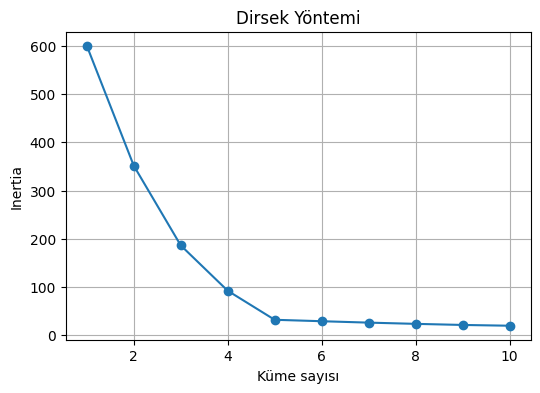


Seçilen K = 5, Silhouette skoru = 0.715



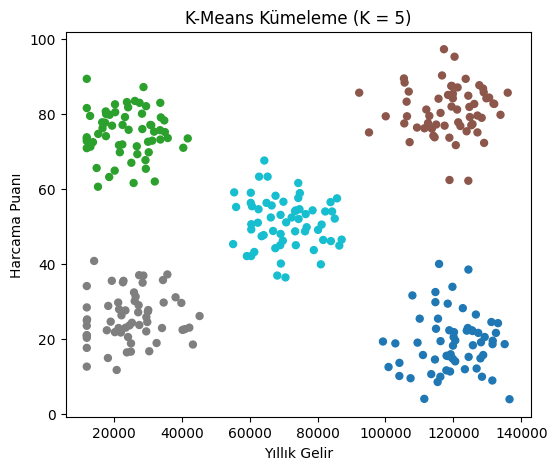


Yorum: Dirsek yöntemi ile K = 5 uygun küme sayısı olarak belirlendi;
bu K için silhouette skoru 0.72 civarındadır (kümelerin iyi ayrışmıştır).

Gelir ve harcama puanı çok farklı ölçeklerde olduğundan standardizasyon yapılmadan
kümeleme yapılırsa gelir değişkeni uzaklık hesabına baskın gelir ve sonuçlar bozulur;
bu yüzden standardizasyon önemlidir.

Bulunan kümeler genellikle şu segmentlere karşılık gelir:
- Düşük gelir - Düşük harcama
- Düşük gelir - Yüksek harcama
- Orta gelir - Orta harcama
- Yüksek gelir - Düşük harcama
- Yüksek gelir - Yüksek harcama

'Kümeleme Analizi' sonucu sonuclar.txt dosyasına kaydedildi.


             ANA MENÜ
1 - Regresyon Analizi
2 - Kümeleme Analizi
3 - Metin Duygu Analizi
4 - Görüntü Sınıflandırma
5 - Çıkış
Seçiminizi girin (1-5): 3

--- Metin Duygu Analizi başlıyor ---

Veri seti önizleme:
                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br 

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_2 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 14s 21ms/step - accuracy: 0.5445 - loss: 0.6799 - val_accuracy: 0.5686 - val_loss: 0.6611
Epoch 2/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.6380 - loss: 0.6106 - val_accuracy: 0.5760 - val_loss: 0.6572
Epoch 3/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - accuracy: 0.6905 - loss: 0.5078 - val_accuracy: 0.5750 - val_loss: 0.6996
Epoch 4/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - accuracy: 0.7134 - loss: 0.4622 - val_accuracy: 0.5343 - val_loss: 0.7580
Epoch 5/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.7167 - loss: 0.4456 - val_accuracy: 0.5761 - val_loss: 0.7646

--> Test Doğruluğu : %57.13 (0.571)
--> Test Kaybı     : 0.778

Yorum:
Model, IMDB film yorumları üzerinde eğitildi ve test doğruluğu 0.571 olarak ölçüldü.

SimpleRNN, uzun metinlerde önceki bilgiyi tam koruyamadığından (kaybolan gradyan sorunu)
LSTM/GRU gibi yapılara göre genelde daha düşük başarı gösterir;
yine de temel bir duygu analizi modeli için maku

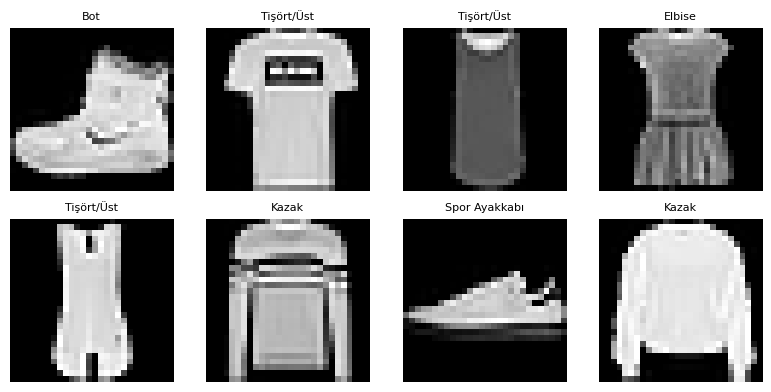

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.8074 - loss: 0.5401 - val_accuracy: 0.8668 - val_loss: 0.3758
Epoch 2/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8719 - loss: 0.3528 - val_accuracy: 0.8842 - val_loss: 0.3286
Epoch 3/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8901 - loss: 0.3064 - val_accuracy: 0.8928 - val_loss: 0.3007
Epoch 4/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8975 - loss: 0.2782 - val_accuracy: 0.8767 - val_loss: 0.3400
Epoch 5/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9076 - loss: 0.2527 - val_accuracy: 0.8985 - val_loss: 0.2819

--> Test Doğruluğu : %89.43 (0.894)
--> Test Kaybı     : 0.293

Yorum:
CNN modeli, Fashion-MNIST veri setinde 0.894 test doğruluğuna ulaştı.

Conv2D katmanları görüntüdeki kenar ve doku gibi yerel örüntüleri öğrenirken,
MaxPooling katmanları boyutu azaltıp modeli hesaplama açısından daha verimli
ve küçük kaymalara karşı daha dayanıklı hale getirir.

Birbirine gö

In [ ]:
def ana_menu():
    while True:
        print("\n" + "=" * 35)
        print("             ANA MENÜ")
        print("=" * 35)
        print("1 - Regresyon Analizi")
        print("2 - Kümeleme Analizi")
        print("3 - Metin Duygu Analizi")
        print("4 - Görüntü Sınıflandırma")
        print("5 - Çıkış")

        secim = input("Seçiminizi girin (1-5): ").strip()

        if secim == "1":
            modul1_regresyon()
        elif secim == "2":
            modul2_kumeleme()
        elif secim == "3":
            modul3_duygu_analizi()
        elif secim == "4":
            modul4_goruntu_siniflandirma()
        elif secim == "5":
            print("Programdan çıkılıyor. İyi çalışmalar!")
            break
        else:
            print("Geçersiz seçim, lütfen 1-5 arasında bir değer girin.")

if __name__ == "__main__":
    ana_menu()


- GENEL DEĞERLENDİRME
> Proje kapsamında dört farklı makine öğrenmesi yöntemi (regresyon, kümeleme, tekrarlayan sinir ağı ve sinir ağı) tek
bir menü tabanlı programda başarıyla bir araya getirilmiştir. Her modül kendi veri setine uygun ön işleme adımlarından
geçirilmiş, ilgili yöntemle eğitilmiş ve sonuçları hem ekrana hem de ortak "sonuclar.txt" dosyasına kaydedilmiştir. En
yüksek başarı görüntü sınıflandırma modülünde (doğruluk = 0.894), en düşük başarı ise metin duygu analizi modülünde
(doğruluk = 0.571) elde edilmiştir. Bu fark, kullanılan mimarilerin (CNN'e karşı SimpleRNN) ilgili veri tiplerini işleme
kapasitesindeki farklılığı yansıtmaktadır.